In [3]:
import yfinance as yf
import pandas as pd

In [4]:
ba = yf.Ticker("BA.L")
ba_data = ba.history(period="2y")
print(ba_data.head())

                                  Open         High          Low        Close  \
Date                                                                            
2024-06-12 00:00:00+01:00  1390.454708  1399.451180  1382.457845  1387.955688   
2024-06-13 00:00:00+01:00  1387.455926  1395.952594  1375.960434  1382.457886   
2024-06-14 00:00:00+01:00  1380.958457  1383.457477  1319.482565  1334.476685   
2024-06-17 00:00:00+01:00  1339.474776  1348.471249  1329.978500  1336.475952   
2024-06-18 00:00:00+01:00  1345.472508  1356.968002  1342.973488  1344.472900   

                            Volume  Dividends  Stock Splits  
Date                                                         
2024-06-12 00:00:00+01:00  4021575        0.0           0.0  
2024-06-13 00:00:00+01:00  7481512        0.0           0.0  
2024-06-14 00:00:00+01:00  4871535        0.0           0.0  
2024-06-17 00:00:00+01:00  5146827        0.0           0.0  
2024-06-18 00:00:00+01:00  5679351        0.0           0.0 

In [5]:
tickers = ["BA.L", "RR.L", "LLOY.L", "ULVR.L"]
data = {}

for t in tickers:
    data[t] = yf.Ticker(t).history(period="2y")

print(data["RR.L"].head())

                                 Open        High         Low       Close  \
Date                                                                        
2024-06-12 00:00:00+01:00  468.821160  472.020634  461.522399  469.321075   
2024-06-13 00:00:00+01:00  469.221092  471.720672  465.321754  467.721344   
2024-06-14 00:00:00+01:00  467.921320  468.921152  452.323936  457.723022   
2024-06-17 00:00:00+01:00  457.323094  465.921654  455.423419  461.522400   
2024-06-18 00:00:00+01:00  464.921844  469.221109  463.022169  467.821350   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-06-12 00:00:00+01:00  31182621        0.0           0.0  
2024-06-13 00:00:00+01:00  25356193        0.0           0.0  
2024-06-14 00:00:00+01:00  19594181        0.0           0.0  
2024-06-17 00:00:00+01:00  31122367        0.0           0.0  
2024-06-18 00:00:00+01:00  15613502        0.0           0.0  


In [6]:
returns = {}

for t in tickers:
    returns[t] = data[t]["Close"].pct_change()

print(returns["RR.L"].head())

Date
2024-06-12 00:00:00+01:00         NaN
2024-06-13 00:00:00+01:00   -0.003409
2024-06-14 00:00:00+01:00   -0.021377
2024-06-17 00:00:00+01:00    0.008301
2024-06-18 00:00:00+01:00    0.013648
Name: Close, dtype: float64


In [7]:
volatility = {}

for t in tickers:
    volatility[t] = returns[t].std()

for t in tickers:
    print(t, volatility[t])

BA.L 0.01951383478380494
RR.L 0.023164489621976155
LLOY.L 0.016968443753217127
ULVR.L 0.011875017324763745


In [8]:
import numpy as np

annual_volatility = {}

for t in tickers:
    annual_volatility[t] = returns[t].std() * np.sqrt(252)

for t in tickers:
    print(t, round(annual_volatility[t] * 100, 2), "%")

BA.L 30.98 %
RR.L 36.77 %
LLOY.L 26.94 %
ULVR.L 18.85 %


In [9]:
returns_df = pd.DataFrame(returns)
correlation = returns_df.corr()
print(correlation)

            BA.L      RR.L    LLOY.L    ULVR.L
BA.L    1.000000  0.454197  0.116034 -0.008693
RR.L    0.454197  1.000000  0.387318  0.037205
LLOY.L  0.116034  0.387318  1.000000  0.062494
ULVR.L -0.008693  0.037205  0.062494  1.000000


In [10]:
portfolio_returns = returns_df.mean(axis=1)
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

print("Portfolio annual volatility:", round(portfolio_volatility * 100, 2), "%")


Portfolio annual volatility: 18.52 %


In [11]:
portfolio_annual_return = portfolio_returns.mean() * 252
risk_free_rate = 0.04  # approx UK risk-free rate

sharpe_ratio = (portfolio_annual_return - risk_free_rate) / portfolio_volatility

print("Portfolio annual return:", round(portfolio_annual_return * 100, 2), "%")
print("Sharpe ratio:", round(sharpe_ratio, 2))

Portfolio annual return: 27.95 %
Sharpe ratio: 1.29


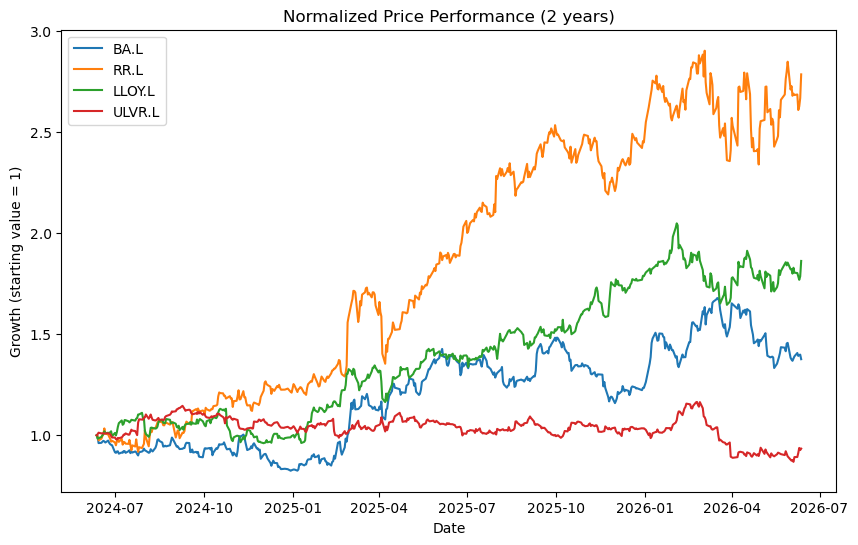

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for t in tickers:
    plt.plot(data[t]["Close"] / data[t]["Close"].iloc[0], label=t)

plt.title("Normalized Price Performance (2 years)")
plt.xlabel("Date")
plt.ylabel("Growth (starting value = 1)")
plt.legend()
plt.savefig("price_performance.png", dpi=150, bbox_inches="tight")
plt.show()

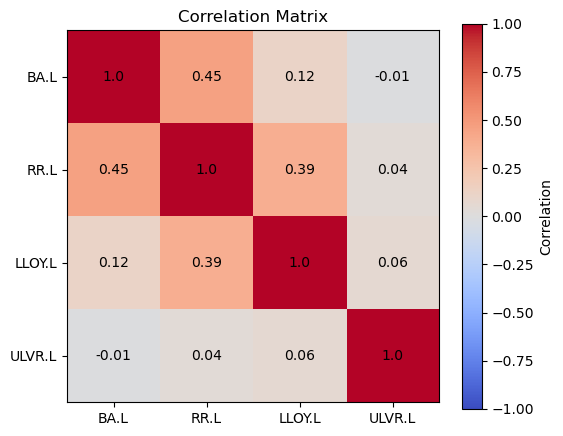

In [14]:
plt.figure(figsize=(6,5))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(tickers)), tickers)
plt.yticks(range(len(tickers)), tickers)
plt.title("Correlation Matrix")

for i in range(len(tickers)):
    for j in range(len(tickers)):
        plt.text(j, i, round(correlation.iloc[i,j], 2), ha="center", va="center")

plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()